In [2]:
from sklearn.datasets import make_moons
X,y = make_moons(n_samples=1000,noise=0.2,random_state=42)
print(X.shape)
print(y.shape)

(1000, 2)
(1000,)


now converting it into tensors before working on it


In [4]:
import torch
X = torch.tensor(X,dtype=torch.float32)
y = torch.tensor(y,dtype=torch.float32).reshape(-1,1)
print(X.shape)
print(y.shape)

torch.Size([1000, 2])
torch.Size([1000, 1])


/tmp/ipykernel_4425/4052375616.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X,dtype=torch.float32)
/tmp/ipykernel_4425/4052375616.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y,dtype=torch.float32).reshape(-1,1)


now we do train test split

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

torch.Size([800, 2])
torch.Size([800, 1])
torch.Size([200, 2])
torch.Size([200, 1])


In [7]:
import torch.nn as nn

model = nn.Linear(2, 1)

print(model)

Linear(in_features=2, out_features=1, bias=True)


In [8]:
predictions = model(X_train)

print("Prediction shape:", predictions.shape)
print(predictions[:5])

Prediction shape: torch.Size([800, 1])
tensor([[ 0.1656],
        [-0.5632],
        [-0.7591],
        [-0.6271],
        [ 0.0852]], grad_fn=<SliceBackward0>)


In [9]:
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

print(model)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)


In [10]:
predictions = model(X_train)

print(predictions[:5])

tensor([[0.2344],
        [0.7454],
        [0.6406],
        [0.6072],
        [0.4668]], grad_fn=<SliceBackward0>)


In [11]:
test_predictions = model(X_test)

for i in range(10):
    print(
        "Predicted:", test_predictions[i].item(),
        "| Actual:", y_test[i].item()
    )

Predicted: 0.41214442253112793 | Actual: 1.0
Predicted: 0.3820821940898895 | Actual: 0.0
Predicted: 0.30057066679000854 | Actual: 1.0
Predicted: 0.44788601994514465 | Actual: 0.0
Predicted: 0.2544906437397003 | Actual: 1.0
Predicted: 0.22051341831684113 | Actual: 1.0
Predicted: 0.35963869094848633 | Actual: 0.0
Predicted: 0.3615403473377228 | Actual: 0.0
Predicted: 0.28504684567451477 | Actual: 1.0
Predicted: 0.4599974453449249 | Actual: 0.0


In [12]:
loss_function = nn.BCELoss()

In [13]:
predictions = model(X_train)

loss = loss_function(predictions, y_train)

print("Loss:", loss.item())

Loss: 0.9616560935974121


In [14]:
loss.backward()

In [15]:
print("Weight gradients:", model[0].weight.grad)
print("Bias gradient:", model[0].bias.grad)

Weight gradients: tensor([[-0.4014,  0.2314]])
Bias gradient: tensor([-0.0236])


In [16]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

In [17]:
optimizer.step()

In [18]:
new_predictions = model(X_train)

print("Old predictions:")
print(predictions[:5])

print("\nNew predictions:")
print(new_predictions[:5])

Old predictions:
tensor([[0.2344],
        [0.7454],
        [0.6406],
        [0.6072],
        [0.4668]], grad_fn=<SliceBackward0>)

New predictions:
tensor([[0.2490],
        [0.7347],
        [0.6330],
        [0.6017],
        [0.4722]], grad_fn=<SliceBackward0>)


In [26]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

loss_function = nn.BCELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

In [27]:
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
  (3): Sigmoid()
)


In [28]:
for epoch in range(1000):

    # 1. Forward pass
    predictions = model(X_train)

    # 2. Calculate loss
    loss = loss_function(predictions, y_train)

    # 3. Backpropagation
    loss.backward()

    # 4. Update weights
    optimizer.step()

    # 5. Clear gradients
    optimizer.zero_grad()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 0.3604
Epoch 200, Loss: 0.3008
Epoch 300, Loss: 0.2839
Epoch 400, Loss: 0.2778
Epoch 500, Loss: 0.2736
Epoch 600, Loss: 0.2693
Epoch 700, Loss: 0.2645
Epoch 800, Loss: 0.2588
Epoch 900, Loss: 0.2522
Epoch 1000, Loss: 0.2446


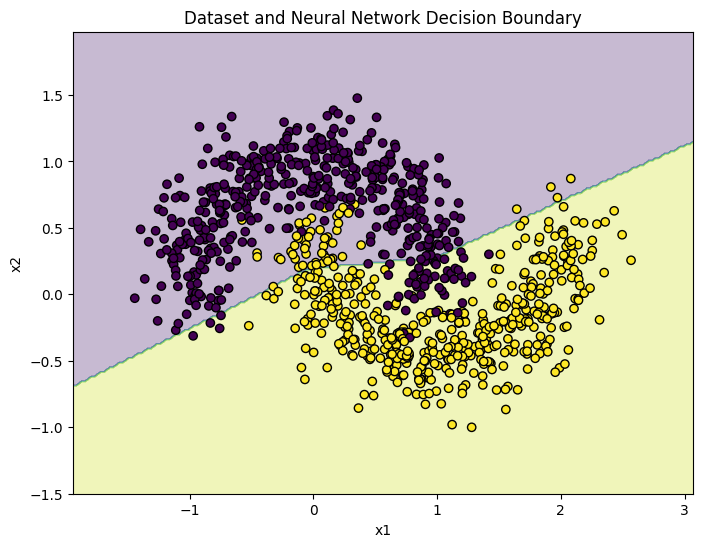

In [29]:
import matplotlib.pyplot as plt

# Put model in evaluation mode
model.eval()

# Create a grid over the input space
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = torch.meshgrid(
    torch.linspace(x_min, x_max, 200),
    torch.linspace(y_min, y_max, 200),
    indexing="ij"
)

# Make grid points
grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)

# Get model predictions for every grid point
with torch.no_grad():
    probabilities = model(grid)

# Convert probabilities to classes
classes = (probabilities >= 0.5).float()

# Reshape back into grid
classes = classes.reshape(xx.shape)

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(8, 6))

# Model's predicted regions
plt.contourf(
    xx.numpy(),
    yy.numpy(),
    classes.numpy(),
    alpha=0.3
)

# Original dataset
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y.flatten(),
    edgecolors="black"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset and Neural Network Decision Boundary")
plt.show()

In [30]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),

    nn.Linear(16, 16),
    nn.ReLU(),

    nn.Linear(16, 1)
)

loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


In [31]:
for epoch in range(2000):

    # Forward pass
    logits = model(X_train)

    # Loss
    loss = loss_function(logits, y_train)

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Clear gradients
    optimizer.zero_grad()

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

Epoch 200, Loss: 0.2932
Epoch 400, Loss: 0.1838
Epoch 600, Loss: 0.1096
Epoch 800, Loss: 0.0831
Epoch 1000, Loss: 0.0715
Epoch 1200, Loss: 0.0671
Epoch 1400, Loss: 0.0647
Epoch 1600, Loss: 0.0632
Epoch 1800, Loss: 0.0622
Epoch 2000, Loss: 0.0613


In [32]:
model.eval()

with torch.no_grad():
    logits = model(X_test)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()

accuracy = (predictions == y_test).float().mean()

print("Test Accuracy:", accuracy.item() * 100, "%")

Test Accuracy: 99.00000095367432 %


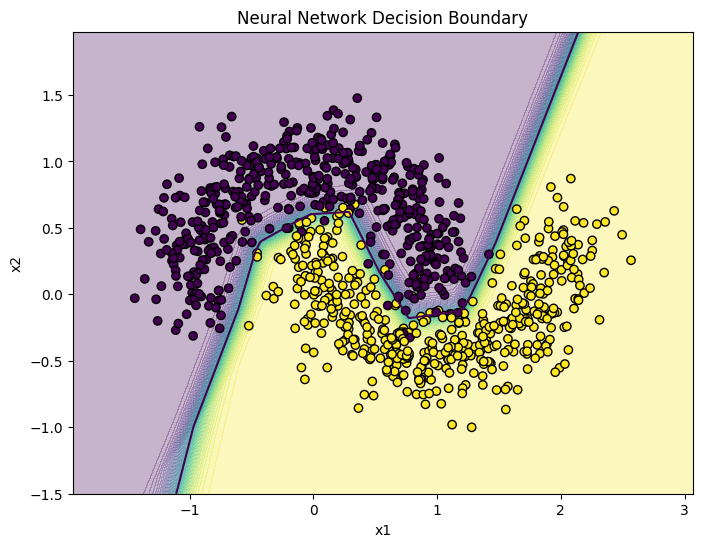

In [33]:
import matplotlib.pyplot as plt

model.eval()

x_min = X[:, 0].min() - 0.5
x_max = X[:, 0].max() + 0.5
y_min = X[:, 1].min() - 0.5
y_max = X[:, 1].max() + 0.5

xx, yy = torch.meshgrid(
    torch.linspace(x_min, x_max, 300),
    torch.linspace(y_min, y_max, 300),
    indexing="ij"
)

grid = torch.stack(
    [xx.flatten(), yy.flatten()],
    dim=1
)

with torch.no_grad():
    probabilities = torch.sigmoid(model(grid))

probabilities = probabilities.reshape(xx.shape)

plt.figure(figsize=(8, 6))

# Probability boundary
plt.contourf(
    xx.numpy(),
    yy.numpy(),
    probabilities.numpy(),
    levels=50,
    alpha=0.3
)

# Decision boundary at probability = 0.5
plt.contour(
    xx.numpy(),
    yy.numpy(),
    probabilities.numpy(),
    levels=[0.5]
)

# Actual points
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y.flatten(),
    edgecolors="black"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Neural Network Decision Boundary")
plt.show()